### Hopf Model

$$\begin{aligned}
\frac{dx_t^i}{dt} &= \left(a^i - (x_t^i)^2 - (y_t^i)^2\right) x_t^i - \omega^i y_t^i \\
&\quad + G \sum_{j=1}^n C^{ij}\!\left(x_{t-\tau^{ij}}^j - x_t^i\right) \\
&\quad + F_0^i \cos(\omega_0^i\, t) + (\beta + \sigma F_0^i)\,\eta_{x,t}^i \\[10pt]
\frac{dy_t^i}{dt} &= \left(a^i - (x_t^i)^2 - (y_t^i)^2\right) y_t^i + \omega^i x_t^i \\
&\quad + G \sum_{j=1}^n C^{ij}\!\left(y_{t-\tau^{ij}}^j - y_t^i\right) \\
&\quad + F_0^i \sin(\omega_0^i\, t) + (\beta + \sigma F_0^i)\,\eta_{y,t}^i
\end{aligned}$$

\
Model parameters — mapped to `HopfModel` arguments:

- $n$ — `nnodes`: number of brain regions
- $x_t^i,\, y_t^i$ — real and imaginary state variables for node $i$ ($x$ is used as the BOLD proxy)
- $a^i$ — `a`: bifurcation parameter per node. $a^i < 0$: damped; $a^i > 0$: limit cycle; $a^i \approx 0$: critical
- $\omega^i$ — `w`: natural oscillation frequency per node (Hz, converted to rad/s internally)
- $G$ — `G`: global coupling scaling factor
- $C^{ij}$ — `C`: connectivity matrix (SC or optimised GEC); diffusive coupling so only the difference $x_j - x_i$ drives flow
- $\tau^{ij}$ — `D`, `MD`: conduction delay from node $j$ to $i$. `D` is the fibre-length matrix; `MD` sets the mean delay (s). Only the presynaptic state is delayed.
- $F_0^i$ — `F0`: amplitude of sinusoidal forcing per node (0 = no stimulation)
- $\omega_0^i$ — `F0_w`: frequency of external forcing per node (Hz, converted to rad/s internally)
- $\beta$ — `beta`: isotropic noise amplitude; each node receives $\mathcal{N}(0,\,\beta^2\,\mathrm{d}t)$ independently on $x$ and $y$
- $\sigma$ — `sigma`: additional noise for stimulated nodes; effective amplitude becomes $\beta + \sigma F_0^i$

Additional simulation parameters (not in the equation):

- `dt` — Euler–Maruyama integration timestep (s)
- `teq` — burn-in duration (s) simulated but discarded before recording begins
- `tmax` — duration of the recorded simulation (s)
- `downsamp` — store one sample every `downsamp` integration steps (effective interval = `dt × downsamp`)
- `stim_onset` — time (s) at which stimulation ($F_0$) switches on; set to `teq` to start stimulation only in the recorded phase
- `stim_duration` — duration of the stimulation window (s); `None` = always on
- `use_filt`, `low_cut`, `high_cut`, `filter_order` — optional Butterworth bandpass filter on the $x$ output (default: off)

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from brain_plotting import plot_flatex

plt.rcParams['font.family'] = 'Instrument Sans'
plt.rcParams['figure.dpi'] = 500
plt.rcParams['savefig.dpi'] = 500
plt.rcParams['text.usetex'] = False
plt.rcParams['mathtext.fontset'] = "cm"
rc_fontsize = 15
plt.rcParams.update({'font.size': rc_fontsize})

import Pyfurcate as PF

Freqs = np.load('Freqs.npy')
SC = np.load('SC.npy')
FC = np.load('FC.npy')
nnodes = SC.shape[0]

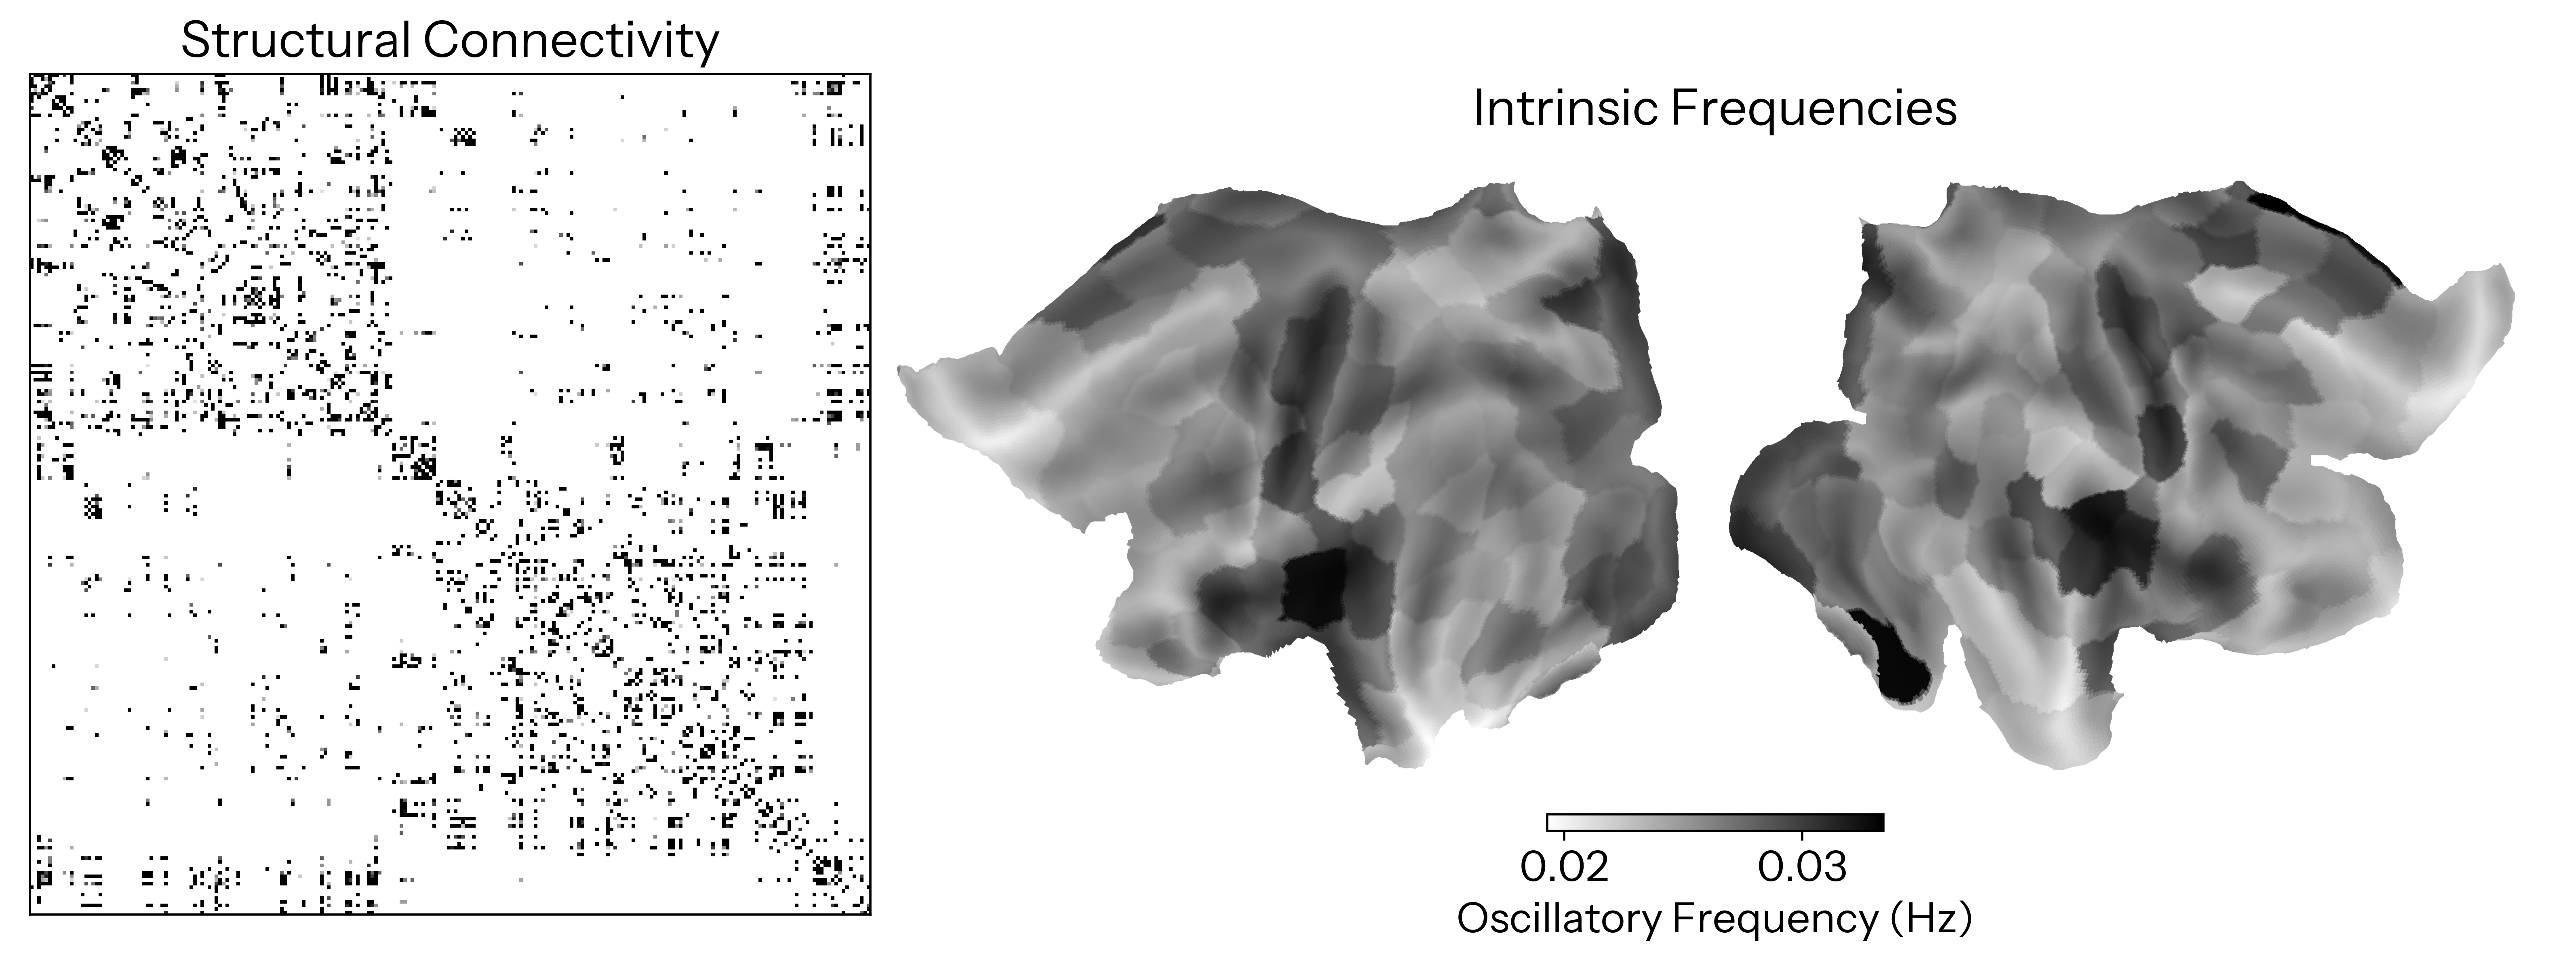

In [ ]:
# Feature constraints

fig, axs = plt.subplots(1, 2, figsize=(13, 5), gridspec_kw={'width_ratios': [1, 2]})
cmap = 'binary'
axs[0].imshow(SC, cmap=cmap, vmin=0, vmax=.001, aspect='equal')
axs[0].set_title('Structural Connectivity')
axs[0].set(xticks=[], yticks=[])
vmin = np.percentile(Freqs, 5); vmax = np.percentile(Freqs, 95)
flat = plot_flatex(Freqs, 'extended_schaefer_200', cmap, bg_on_data=True,
                   vmin=vmin, vmax=vmax, subplot=axs[1])
y0, y1 = axs[1].get_ylim()
axs[1].set_ylim(y0 + (y1 - y0) * 0.1, y1 - (y1 - y0) * 0.1)
axs[1].set_title('Intrinsic Frequencies')
cbar = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=vmin, vmax=vmax))
cbar = fig.colorbar(cbar, ax=axs[1], orientation='horizontal', pad=0, aspect=20, shrink=0.2)
cbar.set_label('Oscillatory Frequency (Hz)', fontsize=15)
plt.tight_layout(w_pad=0.1)

In [ ]:
# Run the wheels off it yipeeeeee

timings = PF.fmri_params(0.72, 14.33 * 2 * 60, verbose=True) # HCP

if not os.path.exists('o-GEC.npy'):

    GEC_results = PF.optimize_GEC(
                    FC, C=SC,
                    use_analytical_grad=False,
                    optimizer_type='adam',
                    lr=2e-3,
                    min_lr=5e-5,
                    grad_clip=1.0,
                    weight_decay=1e-5,
                    tbptt_frac=0.4,
                    teq_opt=60.0,
                    tmax_opt=None,
                    n_simulations=4,
                    n_iterations=1500,
                    scheduler_patience=80,
                    max_gec=0.5,
                    gec_init_max=0.1,
                    allow_negative=True,
                    use_sc_mask=True,
                    use_filt=False,
                    verbose=True,
                    w=Freqs,
                    device=torch.device('cuda:0'),
                    **timings,
    )
    np.save('o-GEC.npy', GEC_results)

else:
    GEC_results = np.load('o-GEC.npy', allow_pickle=True).item()

GEC = GEC_results['optimized_GEC']

fMRI parameters: TR=0.72s, duration=1719.6s
 --------------> dt=0.720s, tmax=1719.6s, downsamp=1, teq=172.0s


Loss elbow @ 220, loss: 0.006
FC elbow @ 158, FC: 0.876
First iteration with r > 0.85: 76


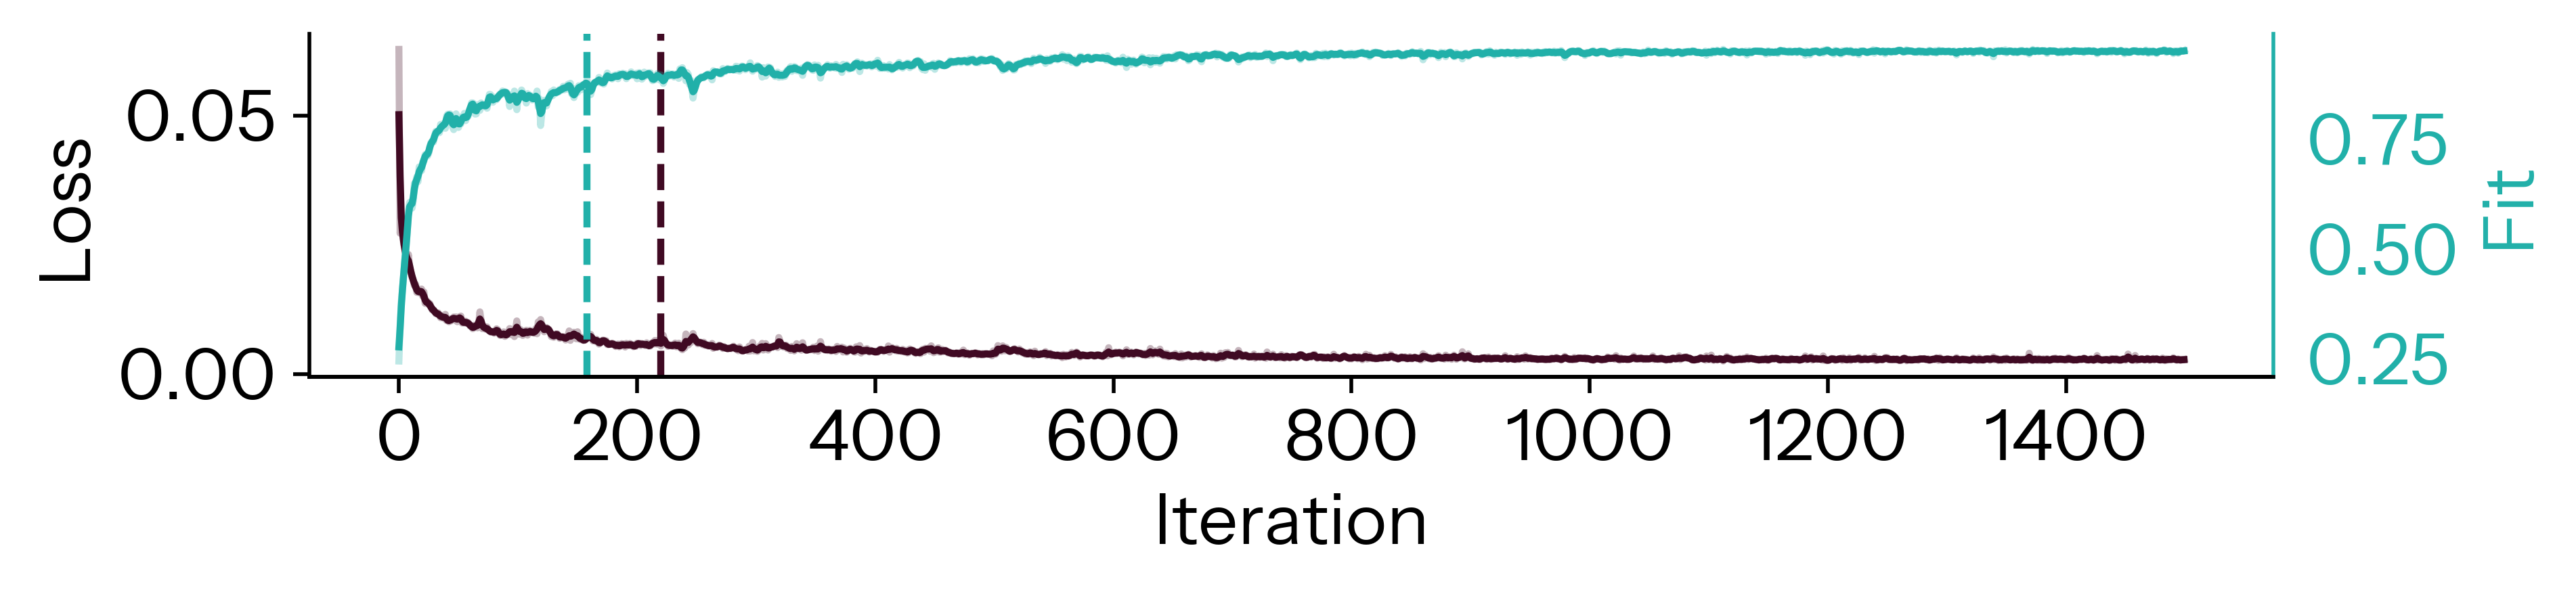

In [ ]:
from scipy.ndimage import gaussian_filter1d

loss = np.array(GEC_results['loss_history'])
fc = np.array(GEC_results['fc_history'])
smoothed_loss = gaussian_filter1d(loss, sigma=1)
smoothed_fc = gaussian_filter1d(fc, sigma=1)

loss_color = "#400A23"
fc_color = "#21B0A9"

min_iter = int(len(loss) * .1)
elbow_loss = np.argmax(np.diff(smoothed_loss, 2)[min_iter:]) + min_iter + 1
elbow_fc = np.argmin(np.diff(smoothed_fc,   2)[min_iter:]) + min_iter + 1  # argmin for rising

fig, ax1 = plt.subplots(figsize=(8, 2))
ax2 = ax1.twinx()

ax1.plot(loss, color=loss_color, alpha=0.3)
ax1.plot(smoothed_loss, color=loss_color)
ax1.axvline(elbow_loss, color=loss_color, linestyle='--')
ax1.axvline(elbow_fc, color=fc_color, linestyle='--')
ax1.set_xlabel('Iteration')
ax1.set_ylabel('Loss')

ax2.plot(fc, color=fc_color, alpha=0.3)
ax2.plot(smoothed_fc, color=fc_color)
ax2.set_ylabel('Fit', color=fc_color)
ax2.tick_params(axis='y', labelcolor=fc_color)
ax2.spines['right'].set_color(fc_color)

sns.despine(ax=ax1)
sns.despine(ax=ax2, left=True, right=False)
plt.tight_layout()

print(f'Loss elbow @ {elbow_loss}, loss: {smoothed_loss[elbow_loss]:.3f}')
print(f'FC elbow @ {elbow_fc}, FC: {smoothed_fc[elbow_fc]:.3f}')

# Luppi et al. (2025) reach r=.85 
print(f'First iteration with r > 0.85: {np.where(fc > 0.85)[0][0]}')

Sim vs Empirical FC correlation): 0.931


[]

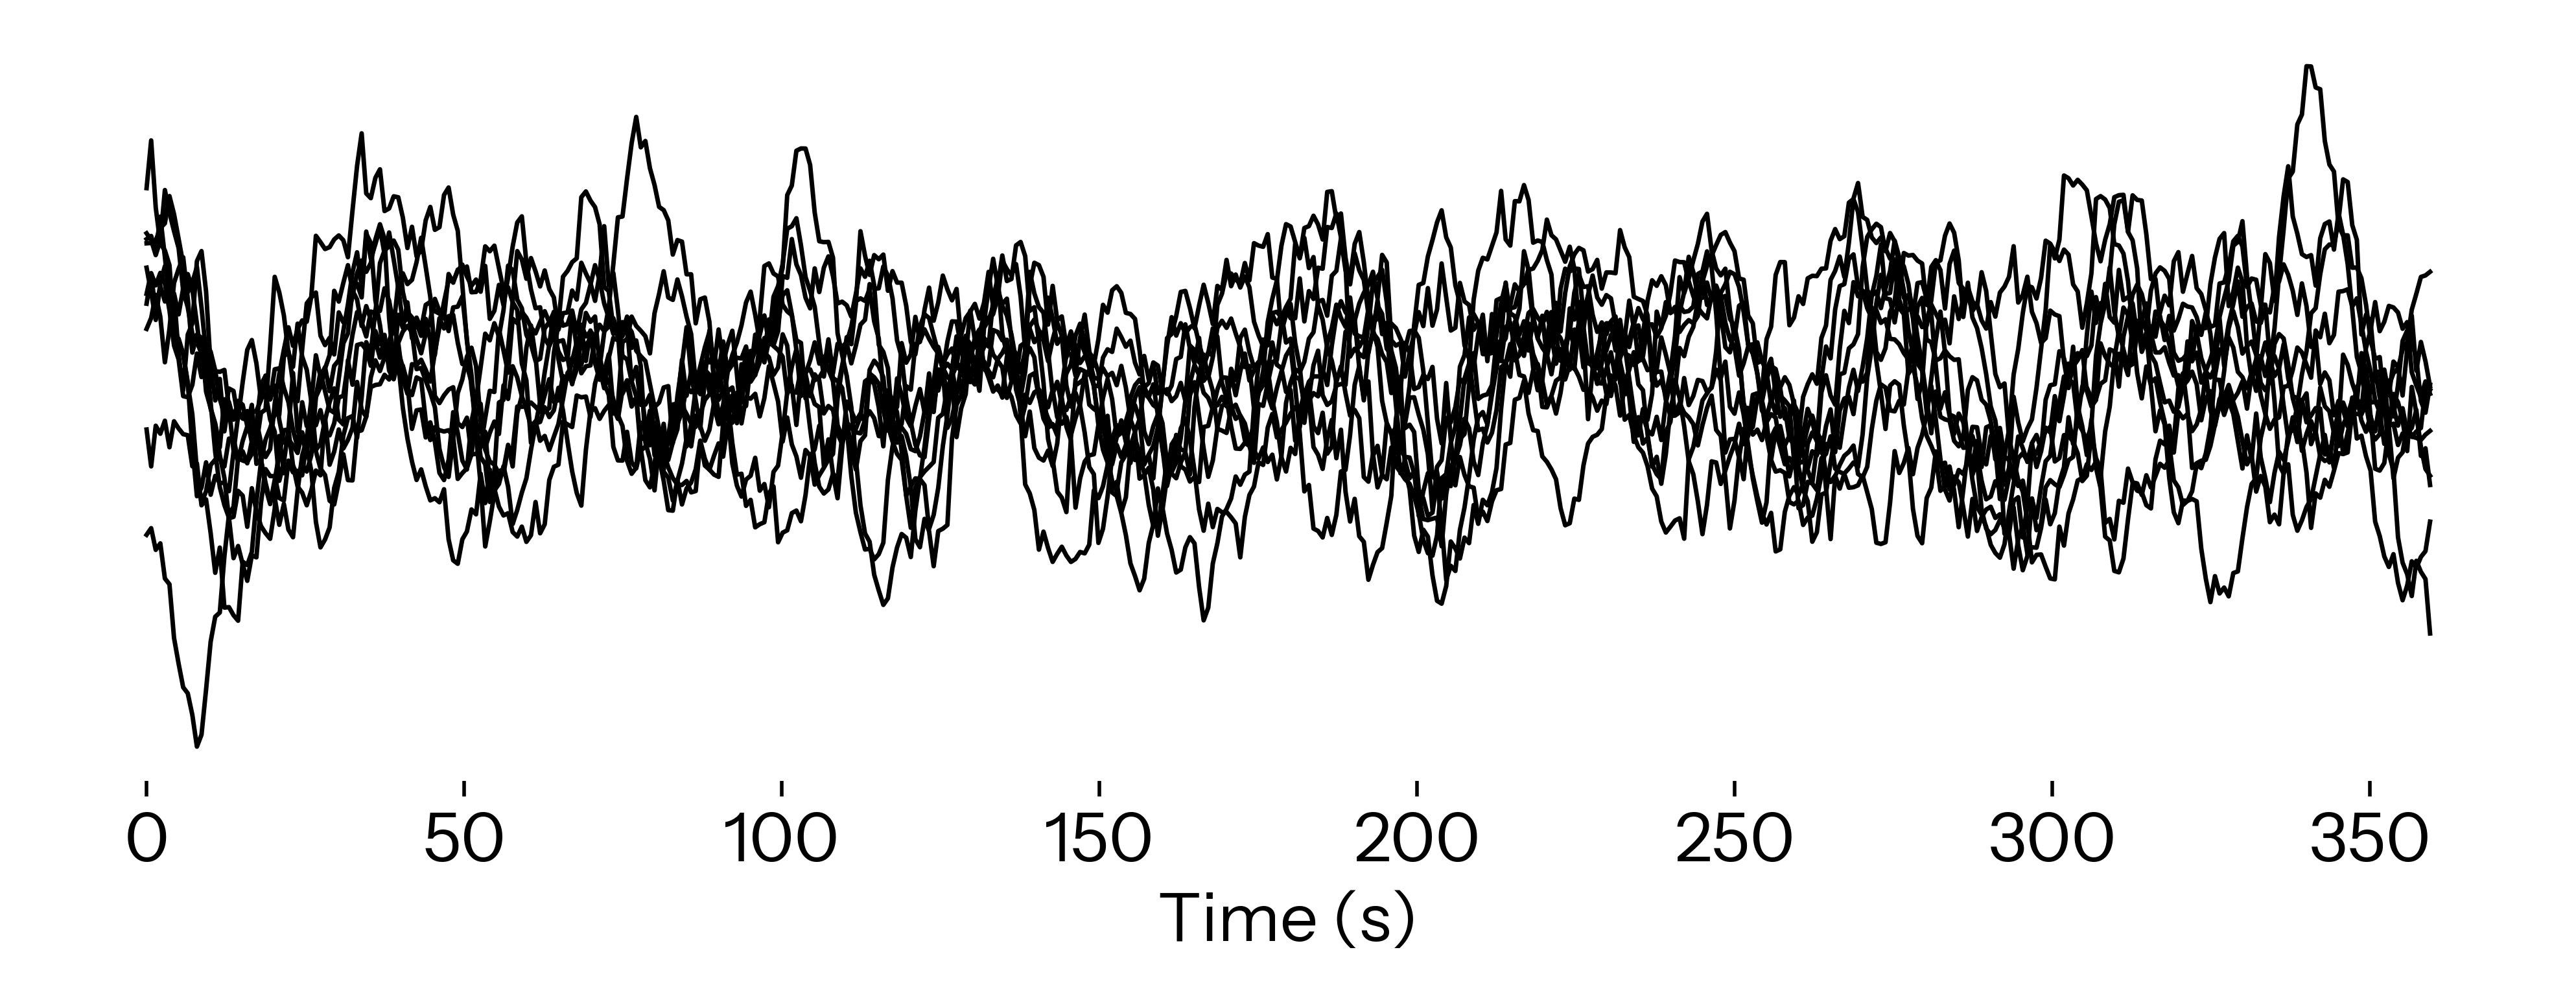

In [85]:
# simulate timeseries with HCP params and check it works as promised!

model = PF.HopfModel(nnodes, C=GEC, w=Freqs, **timings)
results, time_vector = model()
BOLD = model.to_BOLD(results)

FC_sim = np.corrcoef(BOLD)
performance = np.corrcoef(np.triu(FC, k=1).flatten(),
                          np.triu(FC_sim, k=1).flatten())[0, 1]
print(f'Sim vs Empirical FC correlation): {performance:.3f}')

sample_indices = np.random.choice(nnodes, size=10, replace=False)
fig, axs = plt.subplots(1, 1, figsize=(10, 3))
for i in sample_indices:
    axs.plot(time_vector[:500], BOLD[i, :500],
             color='k', lw=1)
axs.set_xlabel('Time (s)')
sns.despine(ax=axs, left=True, bottom=True)
axs.set_yticks([])

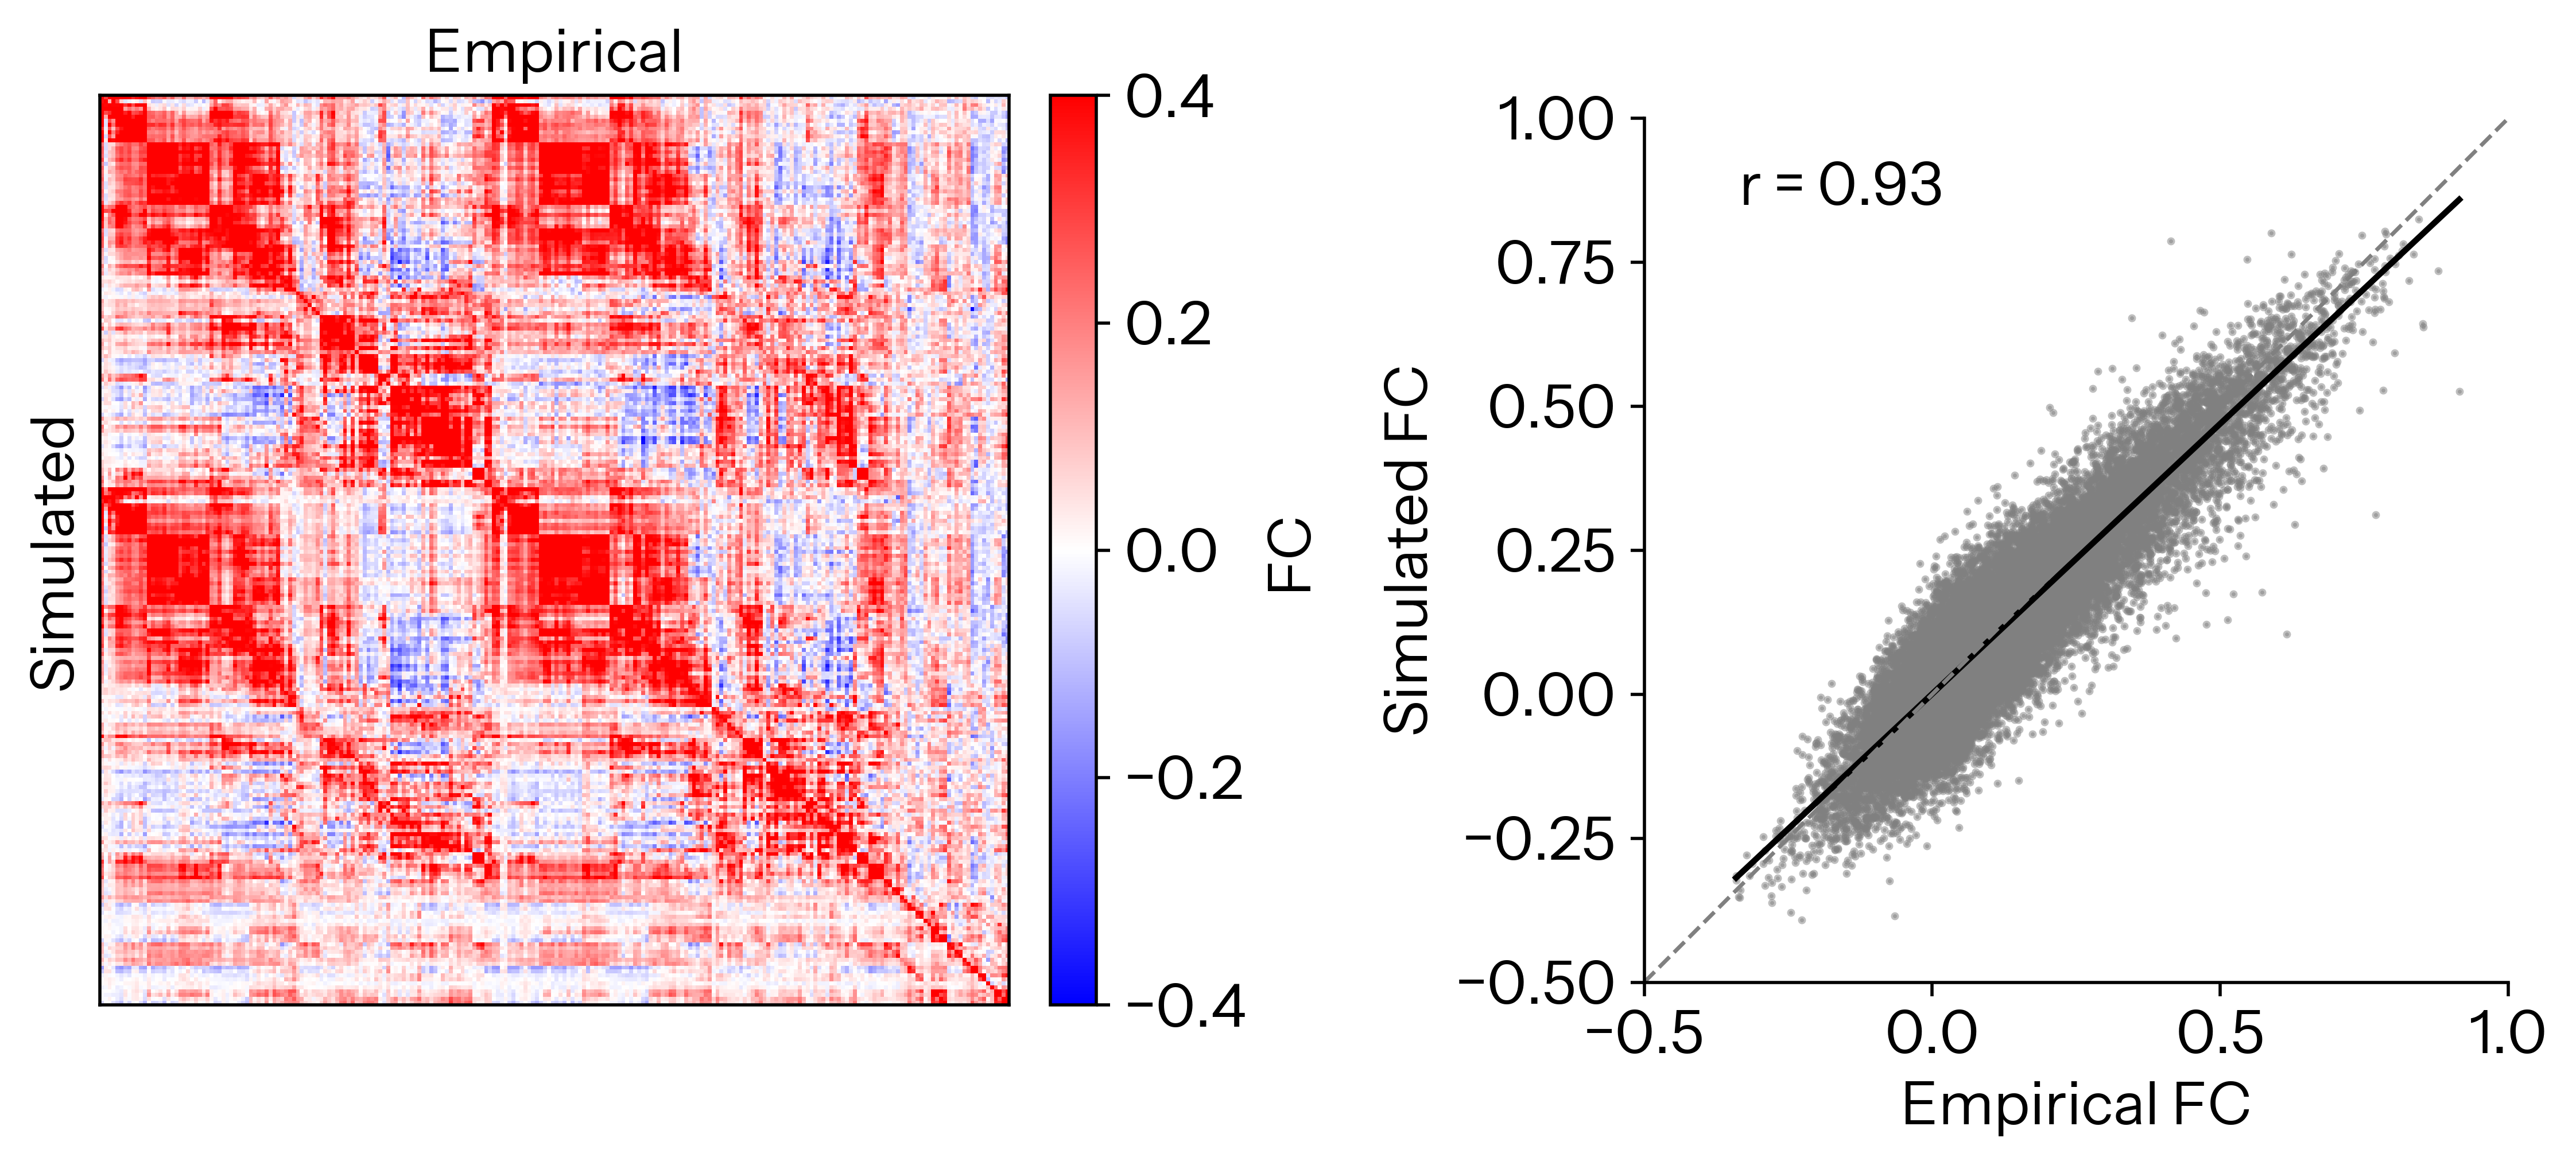

In [104]:
fig, axs = plt.subplots(1, 2, figsize=(11*.85, 5*.85), gridspec_kw={'width_ratios': [1.2, 1]})

combined = np.triu(FC_sim, k=1) + np.tril(FC, k=-1) + (np.eye(FC.shape[0]) * 0.5)
im = axs[0].imshow(combined, cmap='bwr', vmin=-.4, vmax=.4, aspect='equal')
plt.colorbar(im, ax=axs[0], fraction=0.046, pad=0.04).set_label('FC')
#axs[0].plot([-.5, nnodes - 0.5], [-.5, nnodes - 0.5], color='k', lw=.5)
axs[0].set(xticks=[], yticks=[])
axs[0].set_title('Empirical', fontsize=rc_fontsize)
axs[0].set_ylabel('Simulated', fontsize=rc_fontsize)

emp = np.triu(FC, k=1).flatten()
sim = np.triu(FC_sim, k=1).flatten()
axs[1].scatter(emp, sim, s=1, alpha=0.5, color='grey')
sns.regplot(x=emp, y=sim, ax=axs[1], scatter=False, color='black', line_kws={'linewidth': 1.5})
axs[1].set_xlabel('Empirical FC', fontsize=rc_fontsize)
axs[1].set_ylabel('Simulated FC', fontsize=rc_fontsize)
axs[1].text(0.11, 0.9, f'r = {performance:.2f}', transform=axs[1].transAxes, fontsize=rc_fontsize)
sns.despine(ax=axs[1])
axs[1].set_xlim(-.5, 1); axs[1].set_ylim(-.5, 1)
axs[1].set_aspect('equal', adjustable='box')
axs[1].plot([-.5, 1], [-.5, 1], color='grey', linestyle='--', lw=1)

plt.tight_layout()

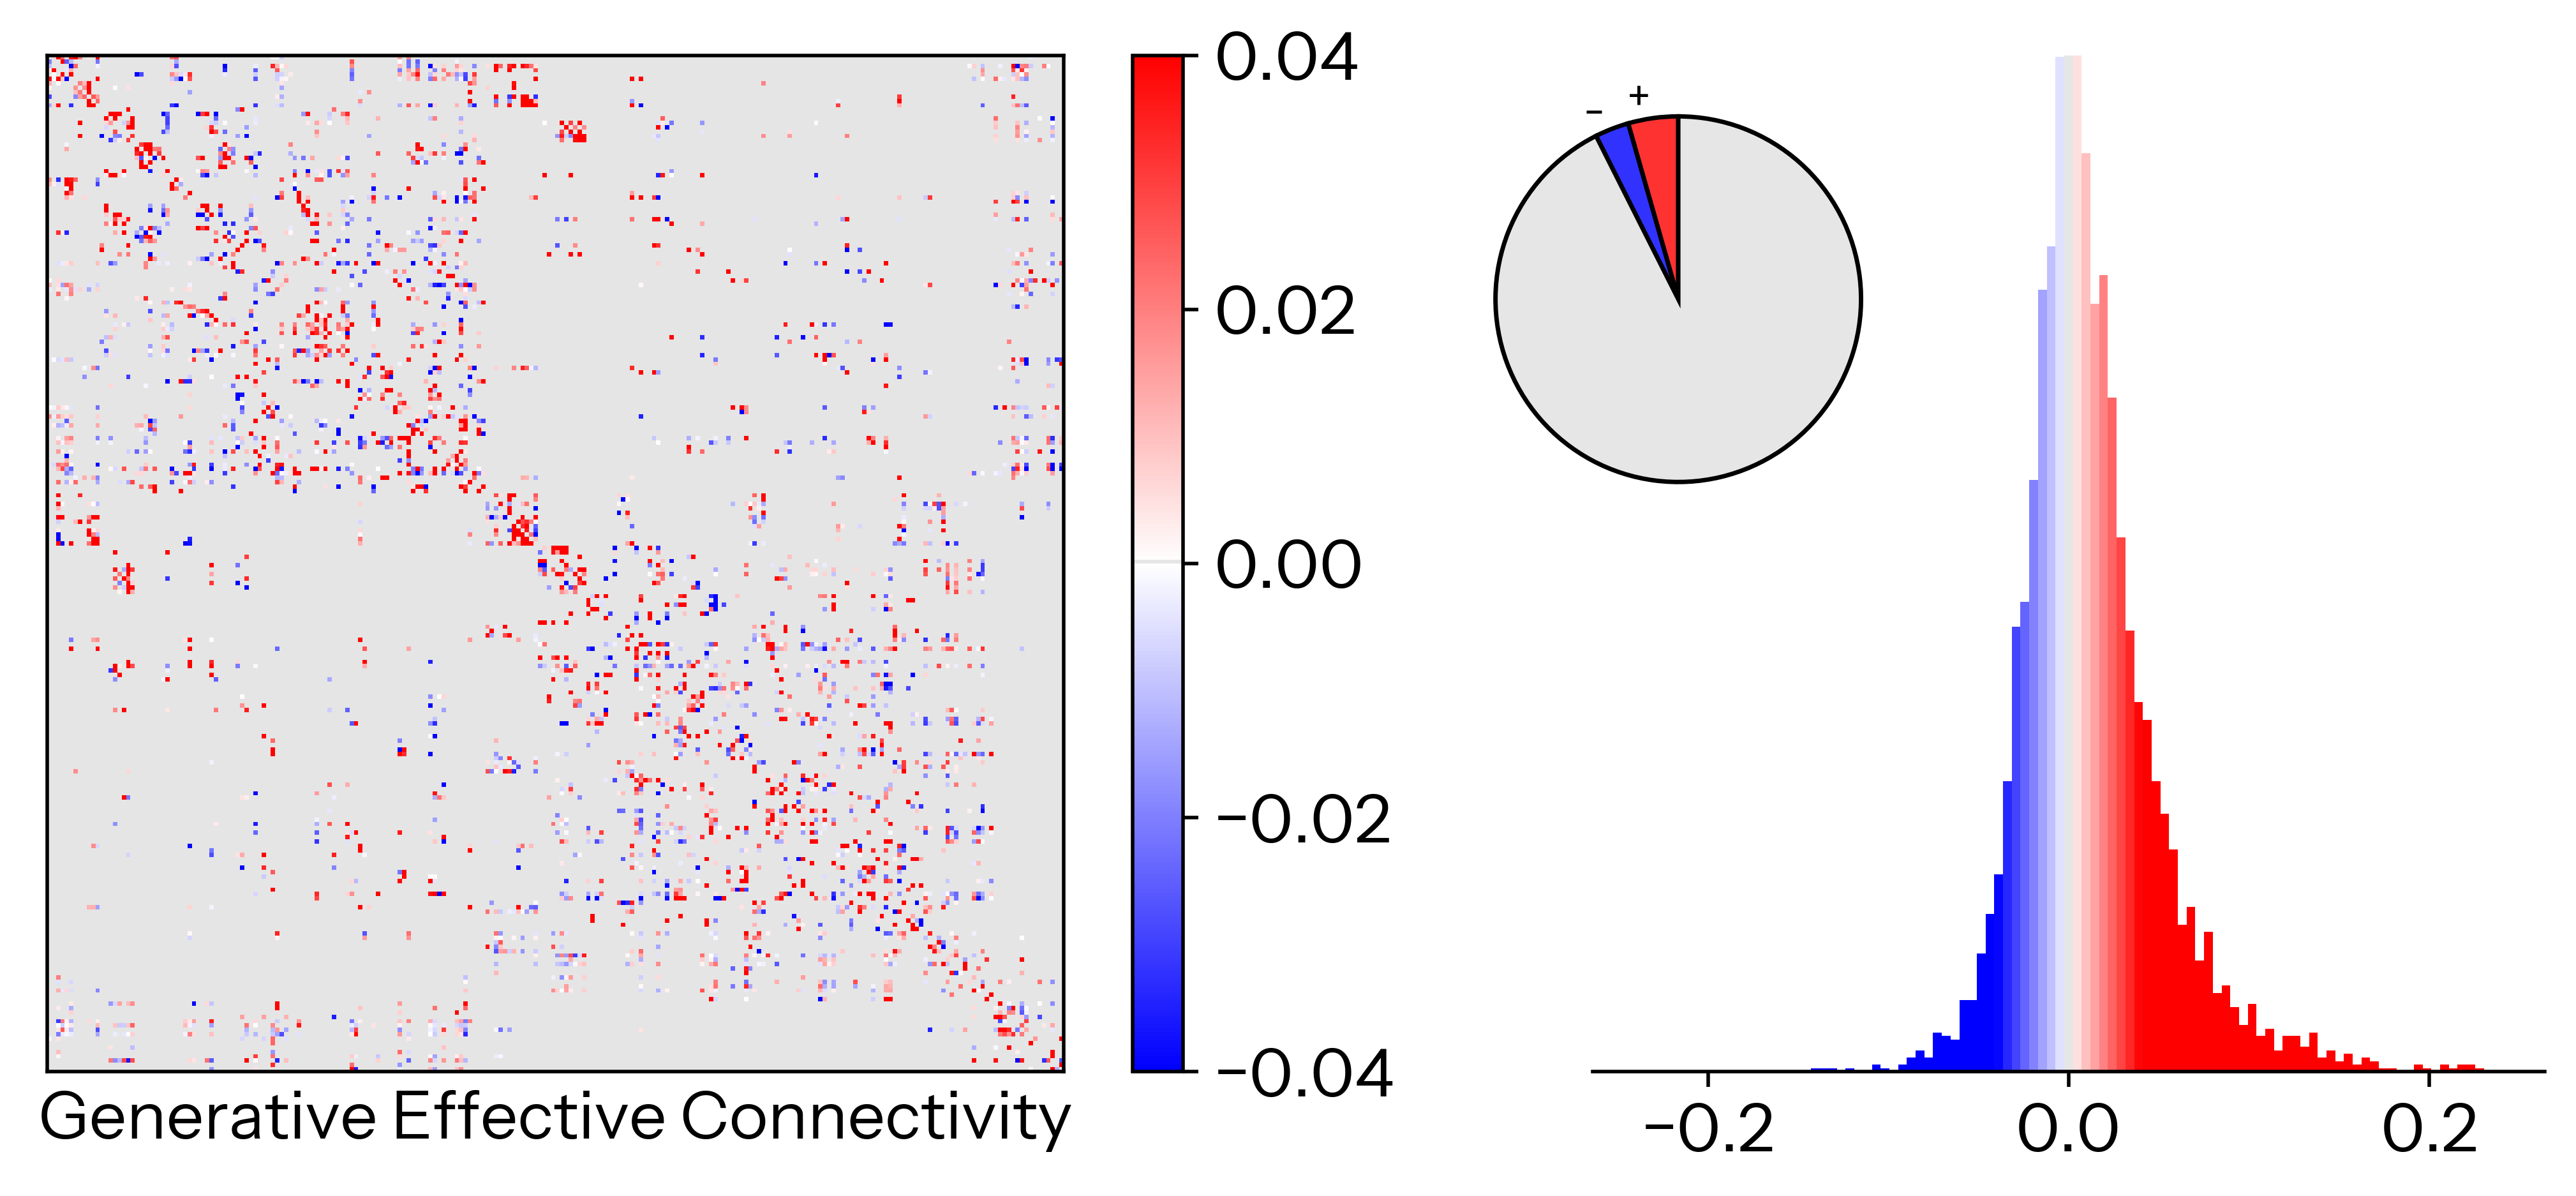

In [154]:
# interrogate GEC

import matplotlib.colors as mcolors

matrix_limit = .04
hist_limit   = .2

norm = plt.Normalize(vmin=-matrix_limit, vmax=matrix_limit)
ccmap = plt.cm.bwr
ccmaplist = [ccmap(i) for i in range(ccmap.N)]
ccmaplist[ccmap.N // 2] = (0.9, 0.9, 0.9, 1.0)
ccmap = mcolors.LinearSegmentedColormap.from_list('custom_bwr', ccmaplist, N=ccmap.N)

fig, axs = plt.subplots(1, 2, figsize=(10, 4), gridspec_kw={'width_ratios': [1.8, 1]})

# Matrix
display_gec = GEC.copy()
np.fill_diagonal(display_gec, 0)
im = axs[0].imshow(display_gec, cmap=ccmap, norm=norm, aspect='equal')
axs[0].set(xticks=[], yticks=[])
axs[0].set_xlabel('Generative Effective Connectivity', fontsize=rc_fontsize)
plt.colorbar(im, ax=axs[0], fraction=0.046, pad=0.04)

# Edge stats
edges = GEC[~np.eye(GEC.shape[0], dtype=bool)]
pos  = np.sum(edges > 0) / len(edges)
neg  = np.sum(edges < 0) / len(edges)
zero = np.sum(edges == 0) / len(edges)

# Histogram (own limits)
bins = np.linspace(-hist_limit * 1.2, hist_limit * 1.2, 100)
hist, bin_edges = np.histogram(edges, bins=bins, density=True)
bin_centers = 0.5 * (bin_edges[1:] + bin_edges[:-1])
axs[1].bar(bin_centers, hist, width=bin_edges[1] - bin_edges[0],
           color=[ccmap(norm(c)) for c in bin_centers], edgecolor='none')
axs[1].set(yticks=[], ylim=(0, np.percentile(hist, 98)))
sns.despine(ax=axs[1], left=True)

# Pie inset
pie_ax = axs[1].inset_axes([-0.15, 0.52, 0.48, 0.48])
pie_ax.pie([pos, neg, zero],
           colors=[ccmap(norm(matrix_limit * 0.8)), ccmap(norm(-matrix_limit * 0.8)), (0.9, 0.9, 0.9, 1.0)],
           labels=['+', '-', ''],
           textprops={'fontsize': 10},
           startangle=90,
           wedgeprops={'edgecolor': 'black'})

plt.tight_layout(w_pad=1)
